In [1]:
from music21 import *
import copy

/Users/skye/.cache/uv/archive-v0/0woMiqm0BCKIsVKkpcGVe/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
score = converter.parse('./assets/flight-of-the-bumblebee-for-b-clarinet.mxl')
score.metadata.composer = "Nikolai Rimsky-Korsakov"
score.metadata.movementName = "Flight of the Bumblebee"

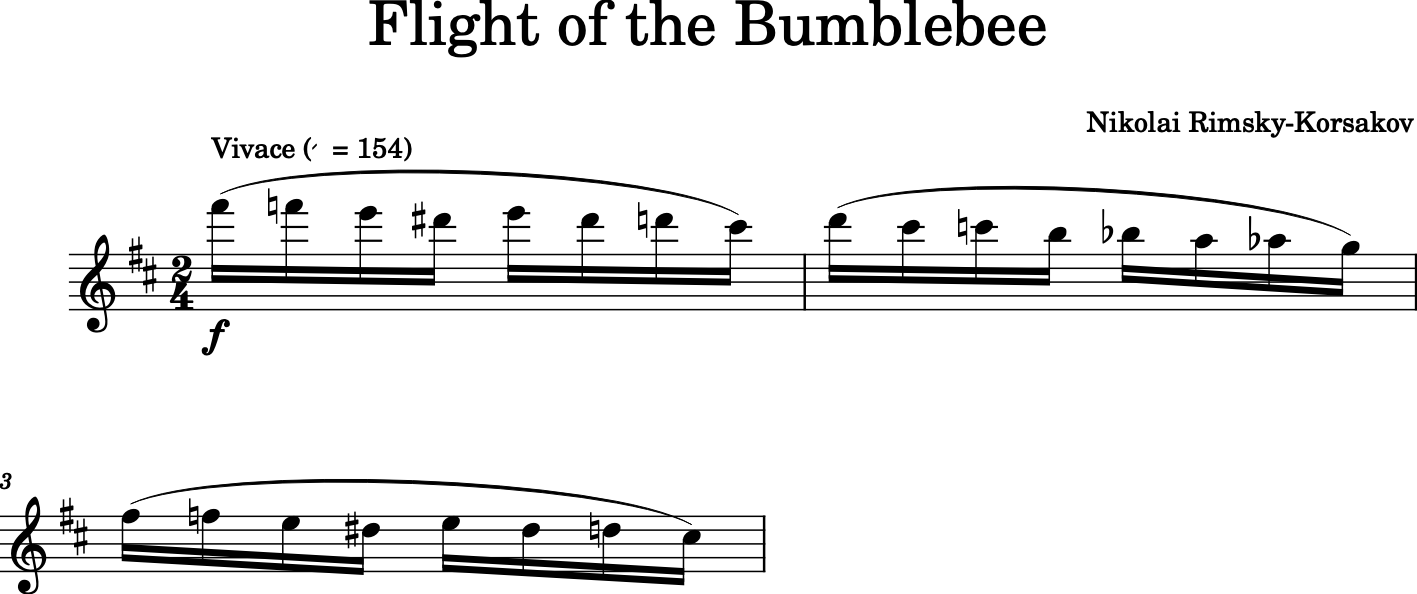

In [3]:
# Show the first three bars
score.measures(1,3).show()

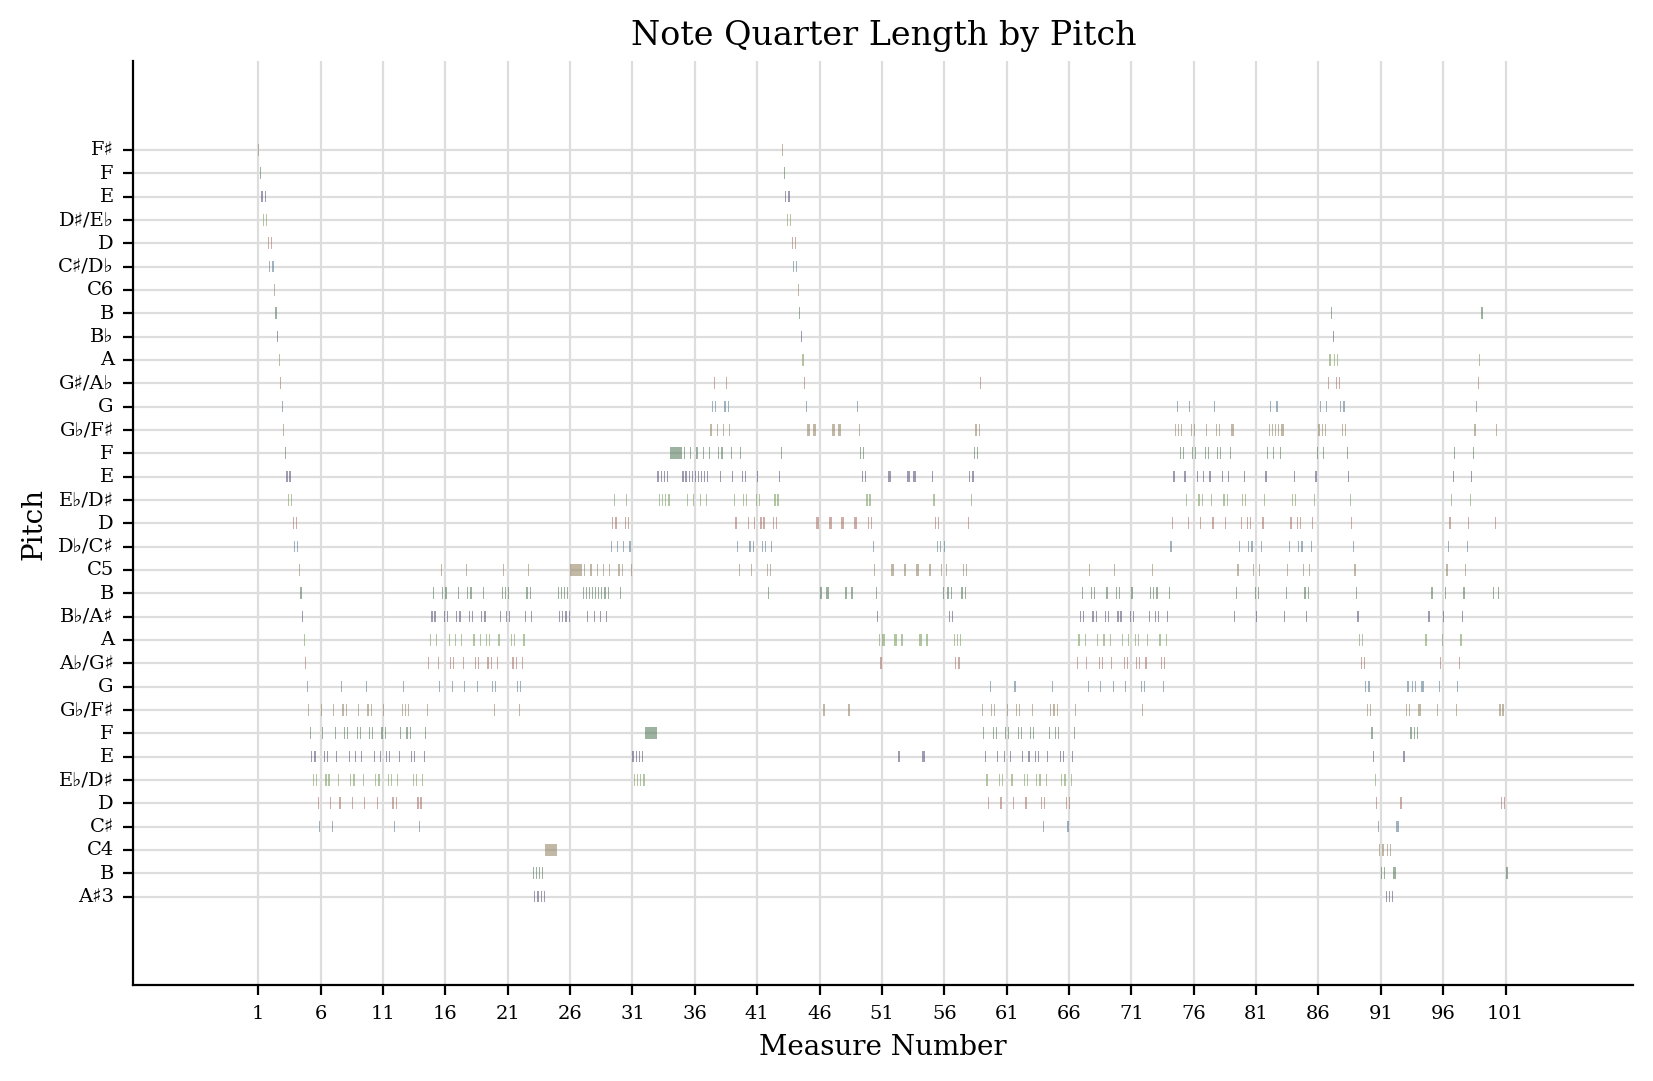

In [4]:
# From looking at the pianoroll, we can see that the bee is going ALLL over the place. 
# Not very streamlined. Lots of extra energy being spent.
score.plot('pianoroll')

In [5]:
score.measures(1,10).show('midi')

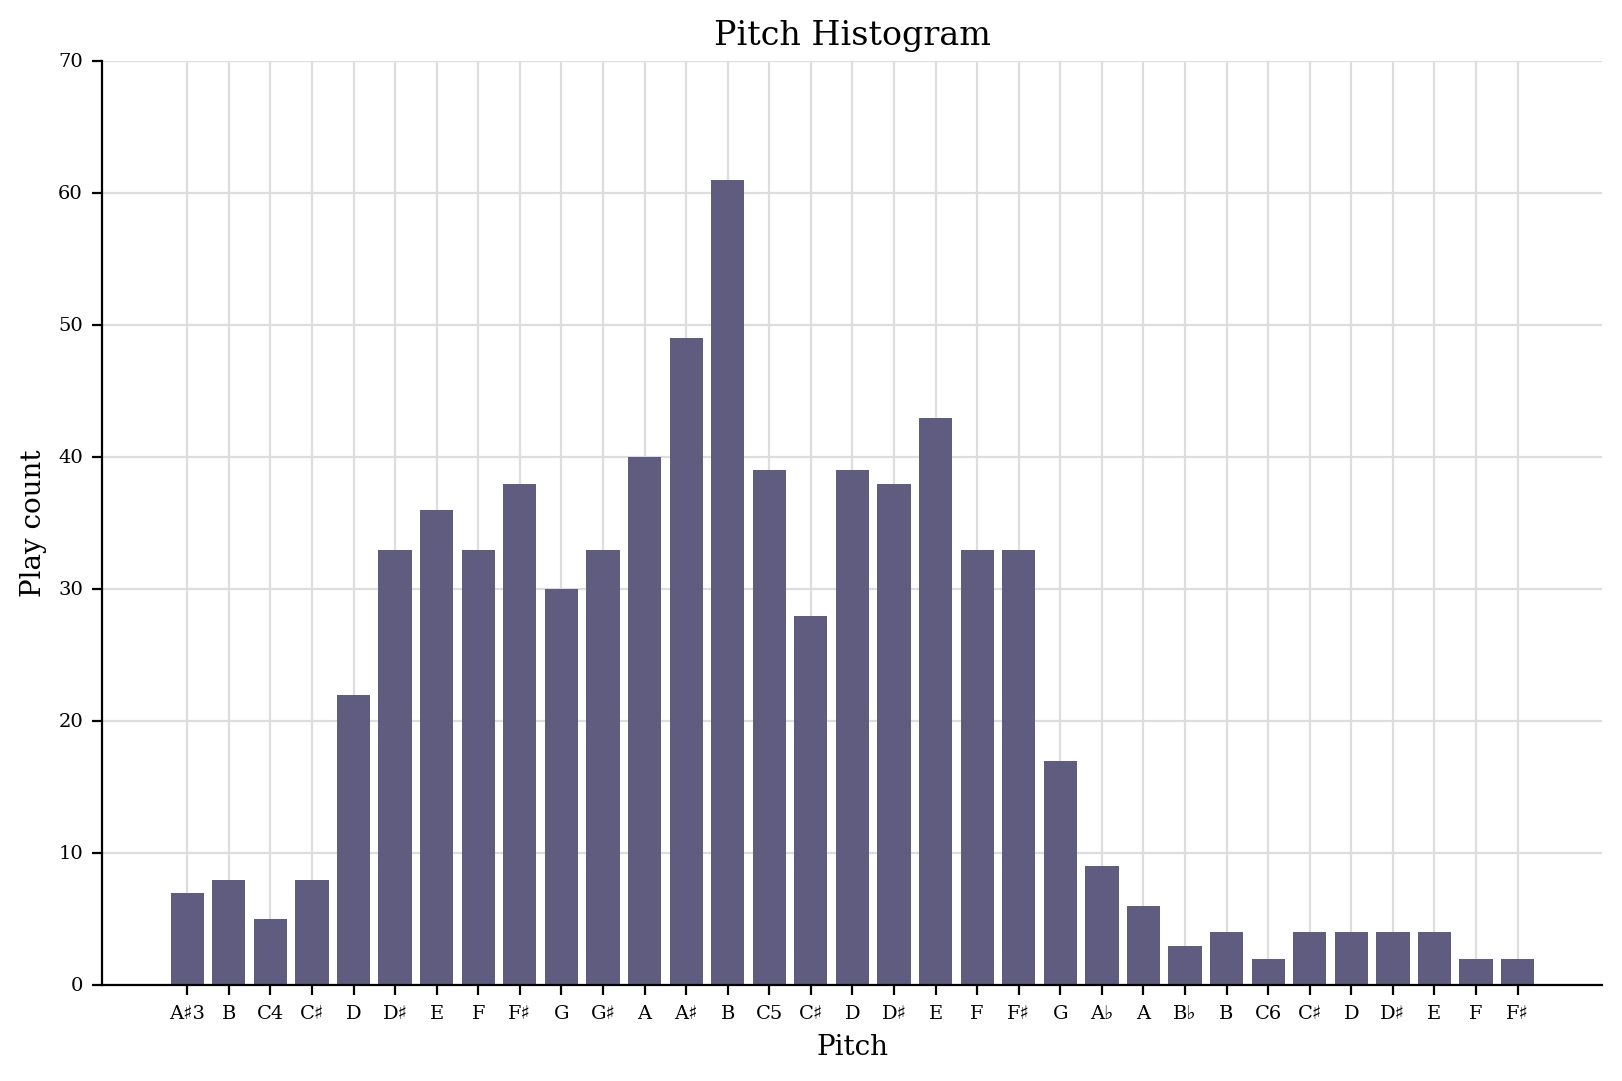

In [6]:
# Looks like we use every single note between the lowest note (A#3) and the highest (F#6)
# at least once. Ironically, we hit the "B" an awful lot!!!! Doesn't really mean anything 
# though, becasue this is a clarinet score, which means it is transposed
score.plot('histogram', 'pitch', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

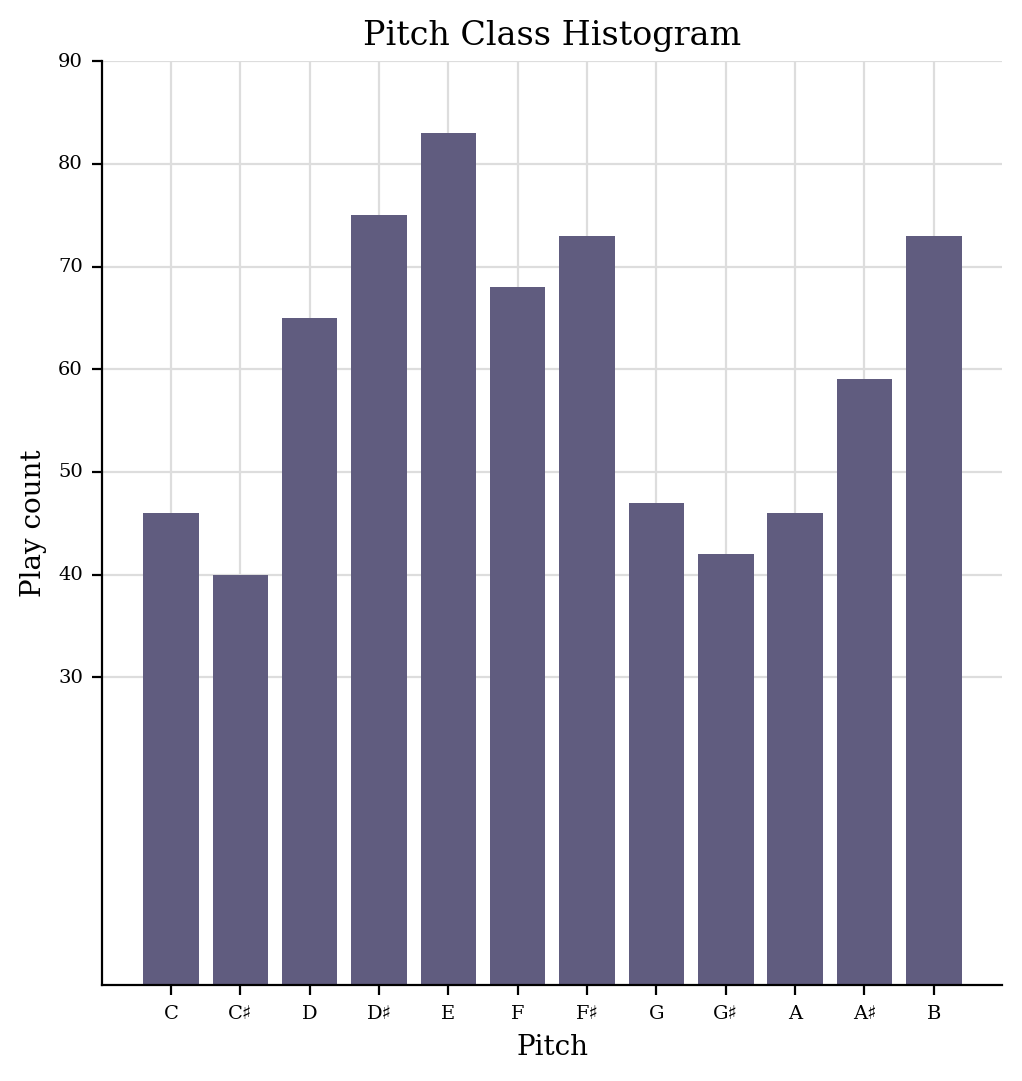

In [7]:
score.plot('histogram', 'pitchClass', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

In [8]:
# What's our note count?
# From a previous notebook we have a function for that
def count_notes_played(input):
    total = 0
    for n in input.recurse().notes:
        if n.tie and n.tie.type != "start":
            continue
        if len(n.expressions) and type(n.expressions[0]) is expressions.Tremolo:
            if n.expressions[0]._numberOfMarks != 1:
                print("Unhandled: tremolo notation with >1 slash")
            total += 2
        else:
            total += 1
    return total
        
count_notes_played(score)

717

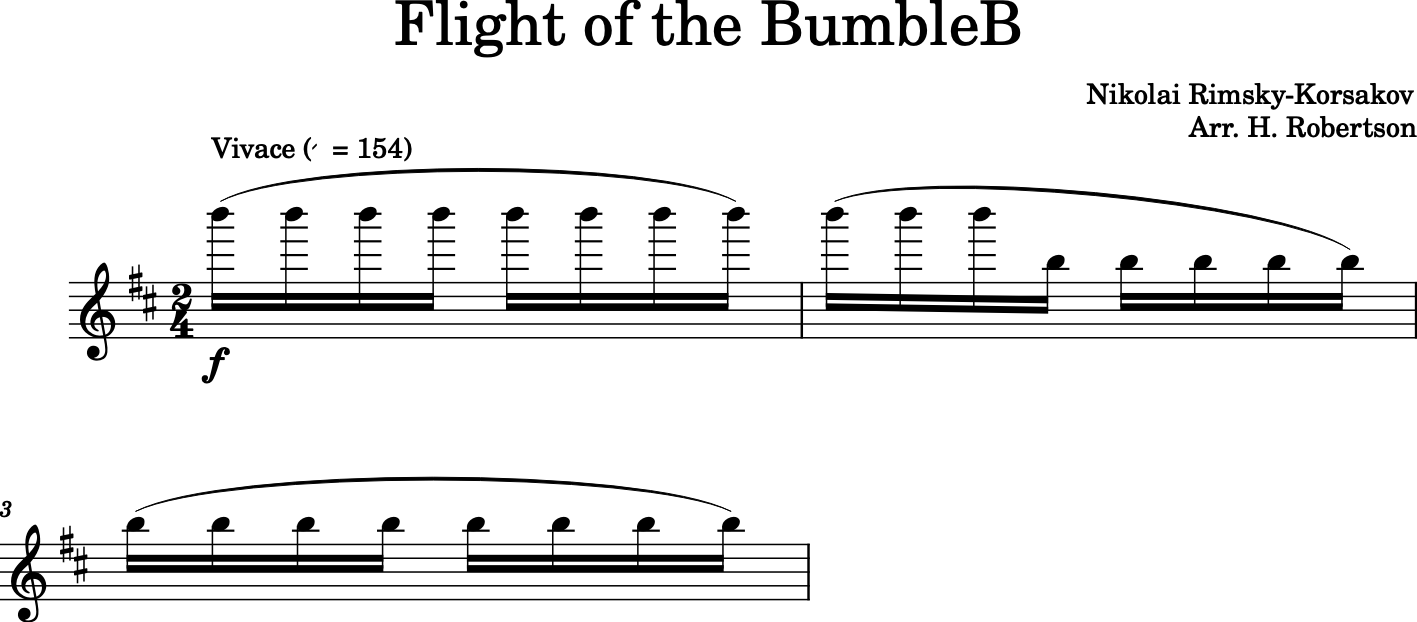

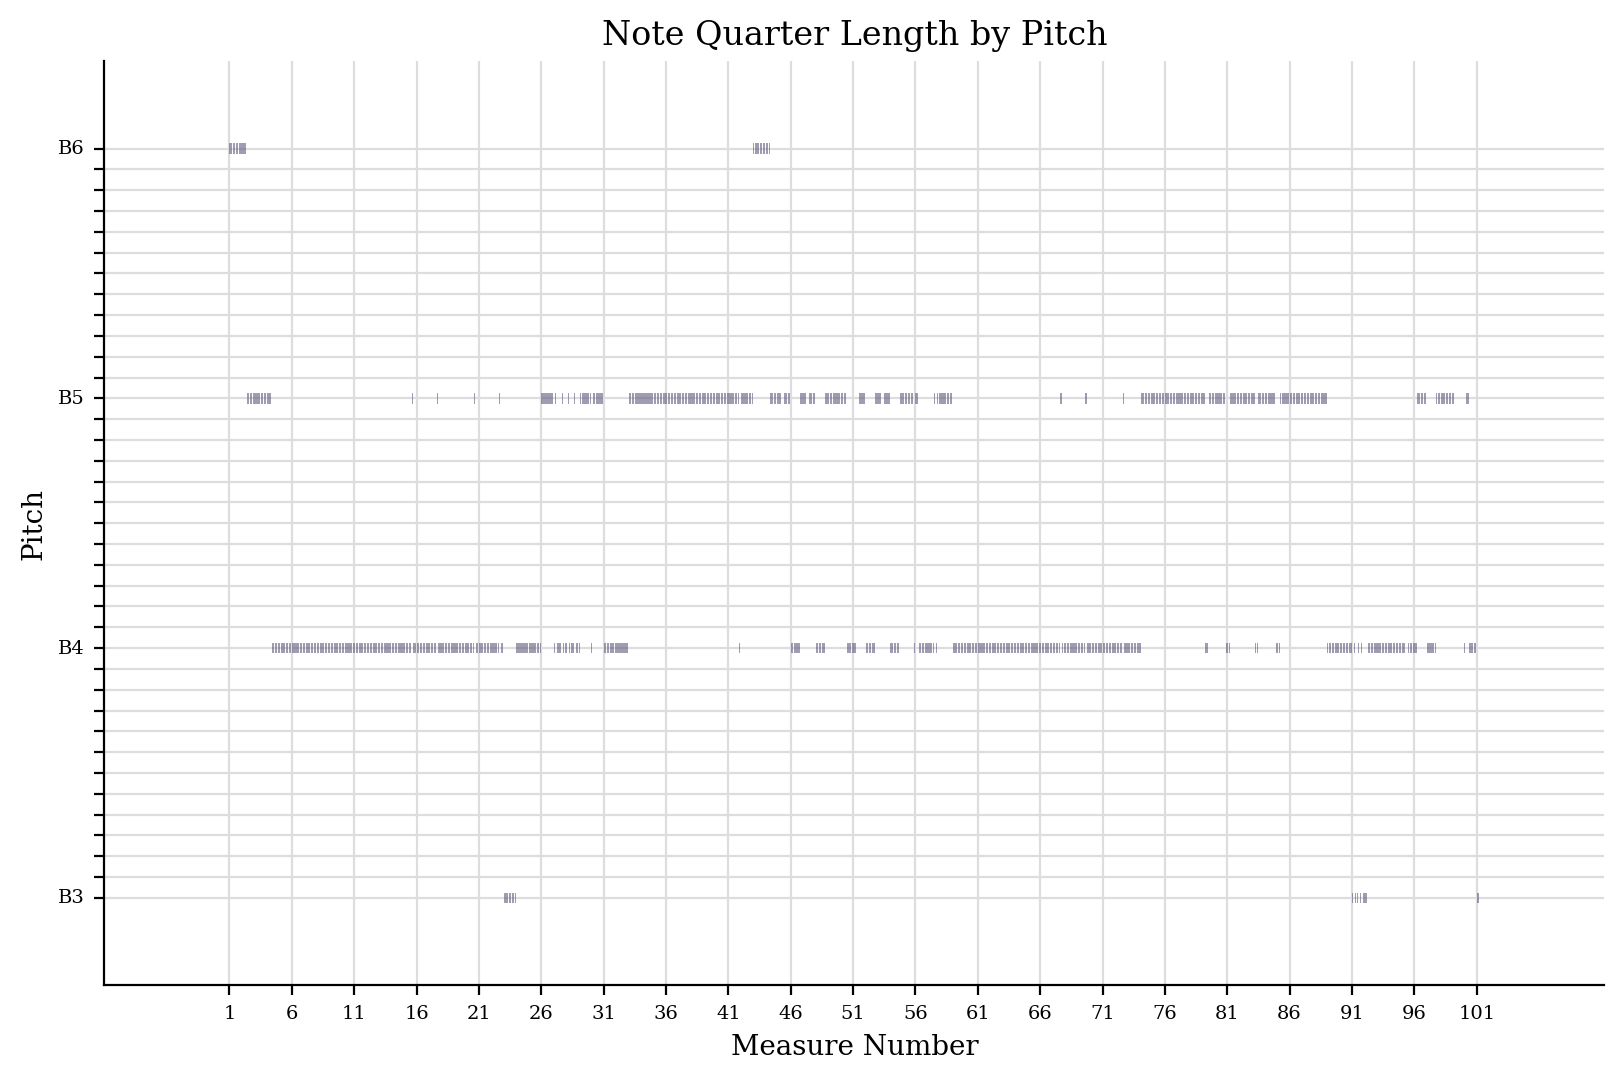

In [9]:
# What happens if we turn this into flight of the bumble B?
# Let's persist the octave of the original, though
score_b = copy.deepcopy(score)
score_b.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_b.metadata.movementName = "Flight of the BumbleB"

for n in score_b.recurse().notes:
    n.pitch.name = ('B')

score_b.measures(1,3).show()
score_b.show('midi')
score_b.plot('pianoroll')

In [41]:
# That first bee did not take a very direct route. 
# Let's update its itinerary, assuming that the bumblebee has traveled exactly 
# where it wanted to travel (i.e., preserve all pitches) and spent as long as it 
# intended at each place based on how tired it was along its journey (preserve duration)
# while re-ordering its destinations (i.e., do not preserve order).

# Aka...flight of the traveling salesbee?

score_traveling = copy.deepcopy(score)
score_traveling.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_traveling.metadata.movementName = "Flight of the Traveling Salesbee"

sorted_notes = sorted(score.recurse().notes, key=lambda n:n.pitch.midi, reverse=True)
for i in range(0, len(score_traveling.recurse().notes)):
    score_traveling.recurse().notes[i].pitch.midi = sorted_notes[i].pitch.midi


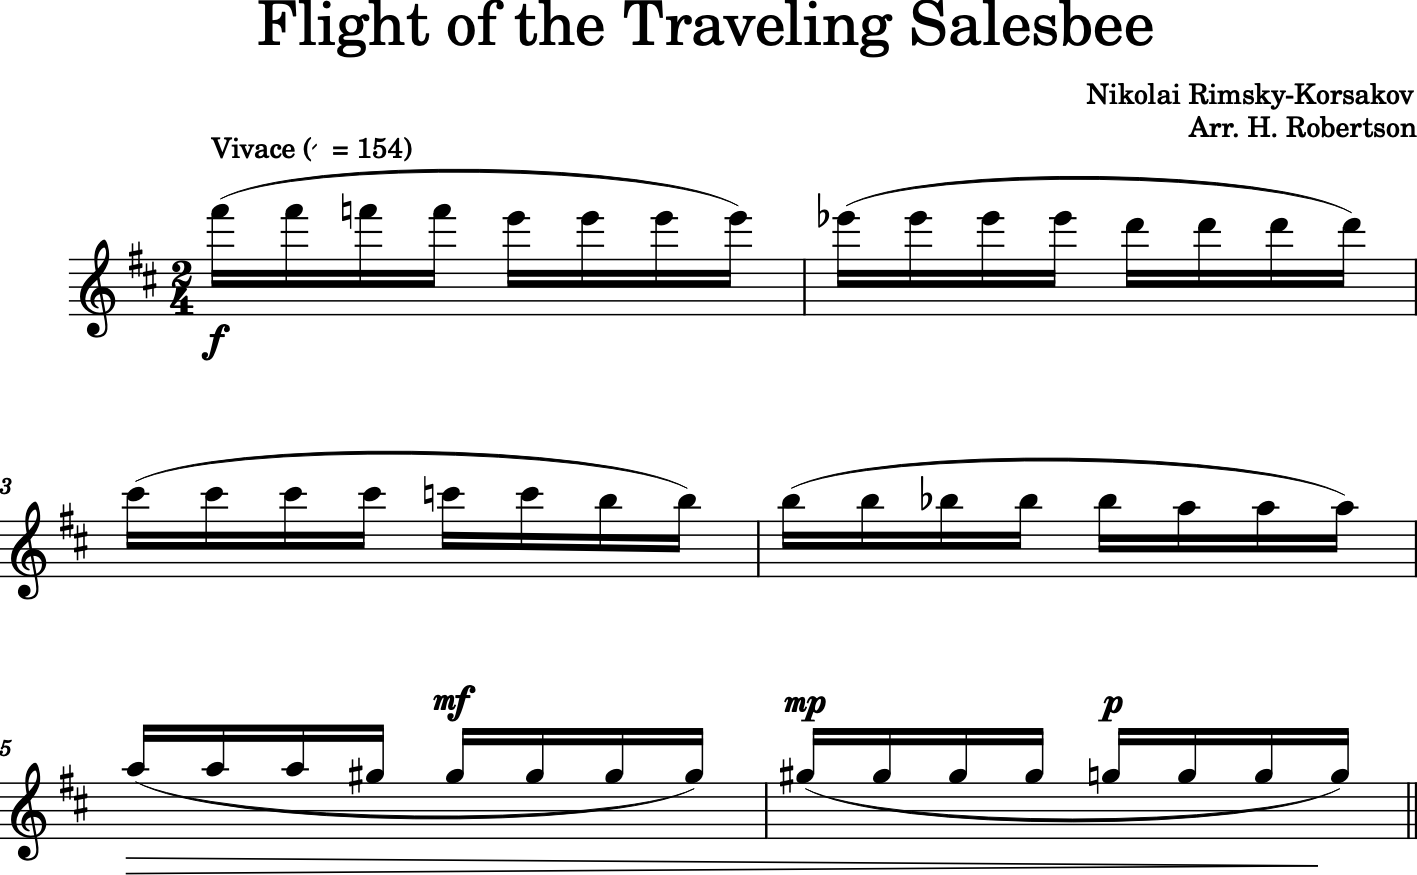

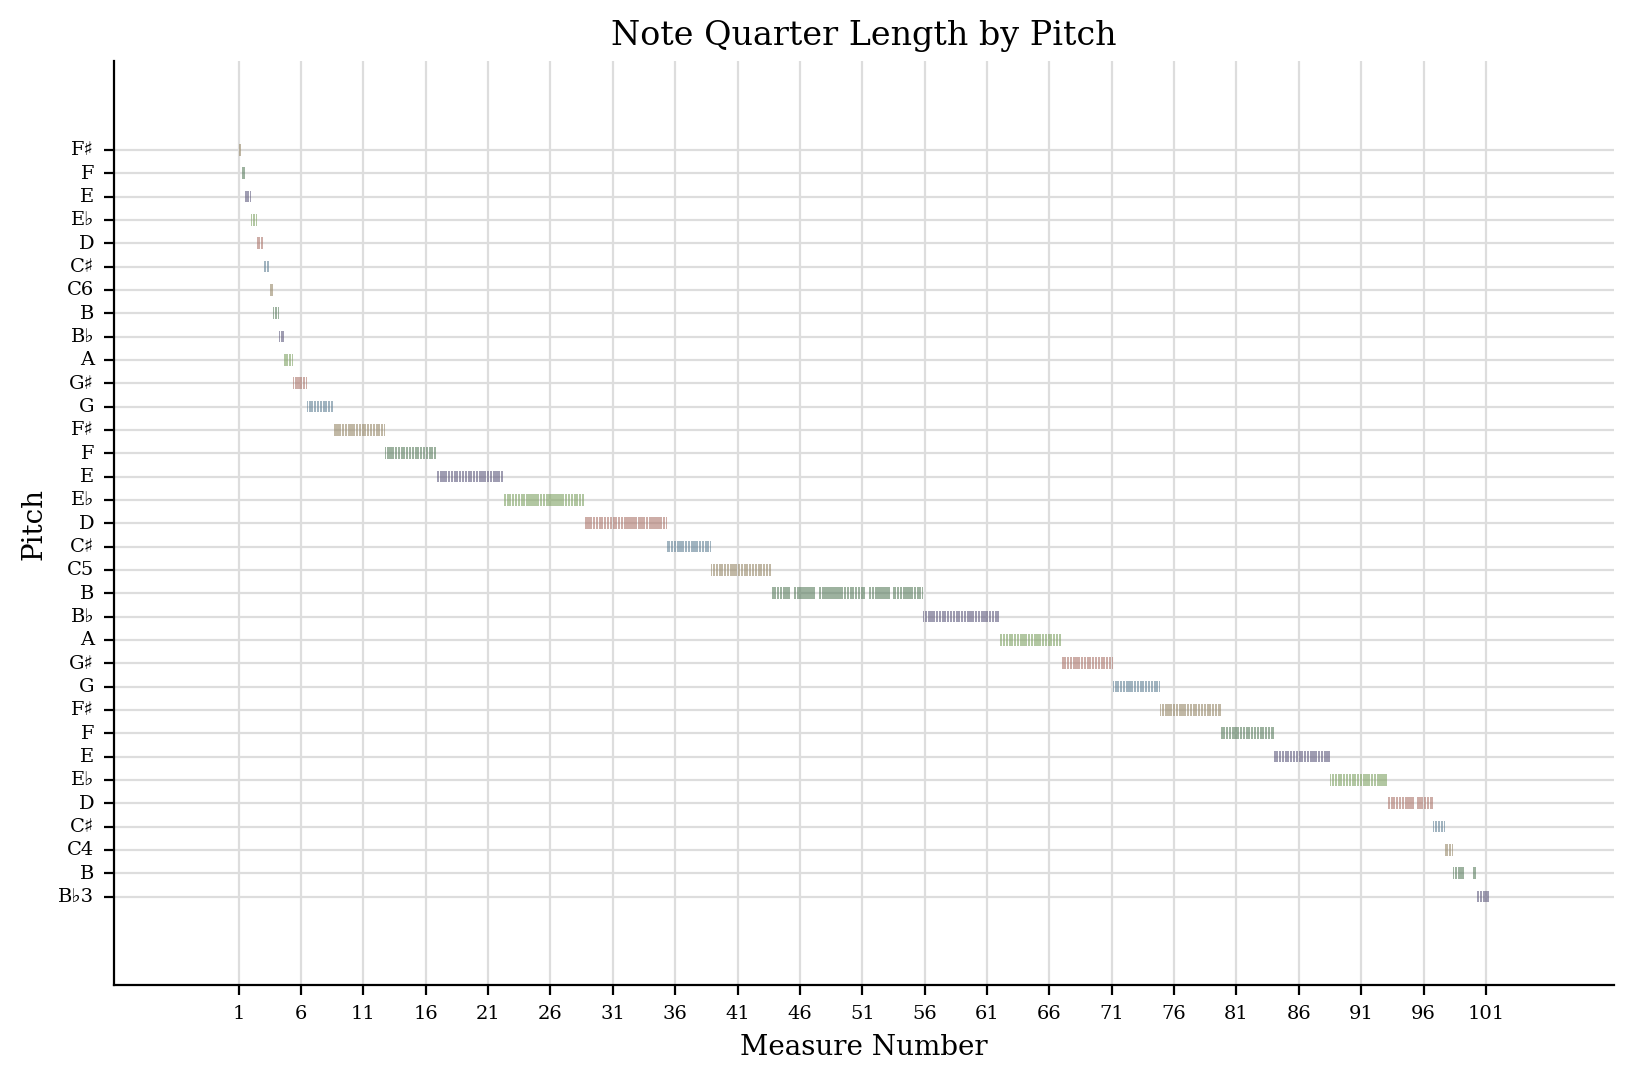

In [42]:
score_traveling.measures(1,6).show()
score_traveling.show('midi')
score_traveling.plot('pianoroll')

In [156]:
# The bee's friend crow has no time for all this bumbling around. 
# Crow agrees that Bumblebee's original route had meaning, but recommends a less 
# circuitous version.
# 
# Crow thinks that Bee shouldn't bother traveling in tiny little bursts (any distance
# of a single semitone) and should instead hang out at its most recent location until 
# a larger movement is required---and then go directly to it. 

score_crow = copy.deepcopy(score)
score_crow.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_crow.metadata.movementName = "As the Bumblebee Flies"

# prev_midi = score_crow.recurse().notes[0].pitch.midi
# for i in range(1, len(score_crow.recurse().notes)):
#     score_crow.recurse().notes[i].pitch.midi = sorted_notes[i].pitch.midi


In [88]:
prev_midi = score_crow.recurse().notes[0].pitch.midi
for i in range(1, len(score_crow.recurse().notes) - 1):
    if type(score_crow.recurse().notes[i]) == note.Rest:
        continue
    tentative_midi = score_crow.recurse().notes[i].pitch.midi
    if abs(tentative_midi - prev_midi) <= 2: #TODO MAKE 1 AGAIN?
        # If it isn't worth the trip, change the current pitch to a rest
        # print(score_crow.recurse().notes[i].pitch.midi)
        score_crow.recurse().notes[i].pitch.midi = 60 #TODO: BROKEN! FIX THIS AND MAKE IT A REST
    else:
        # No change to the current note!
        prev_midi = tentative_midi

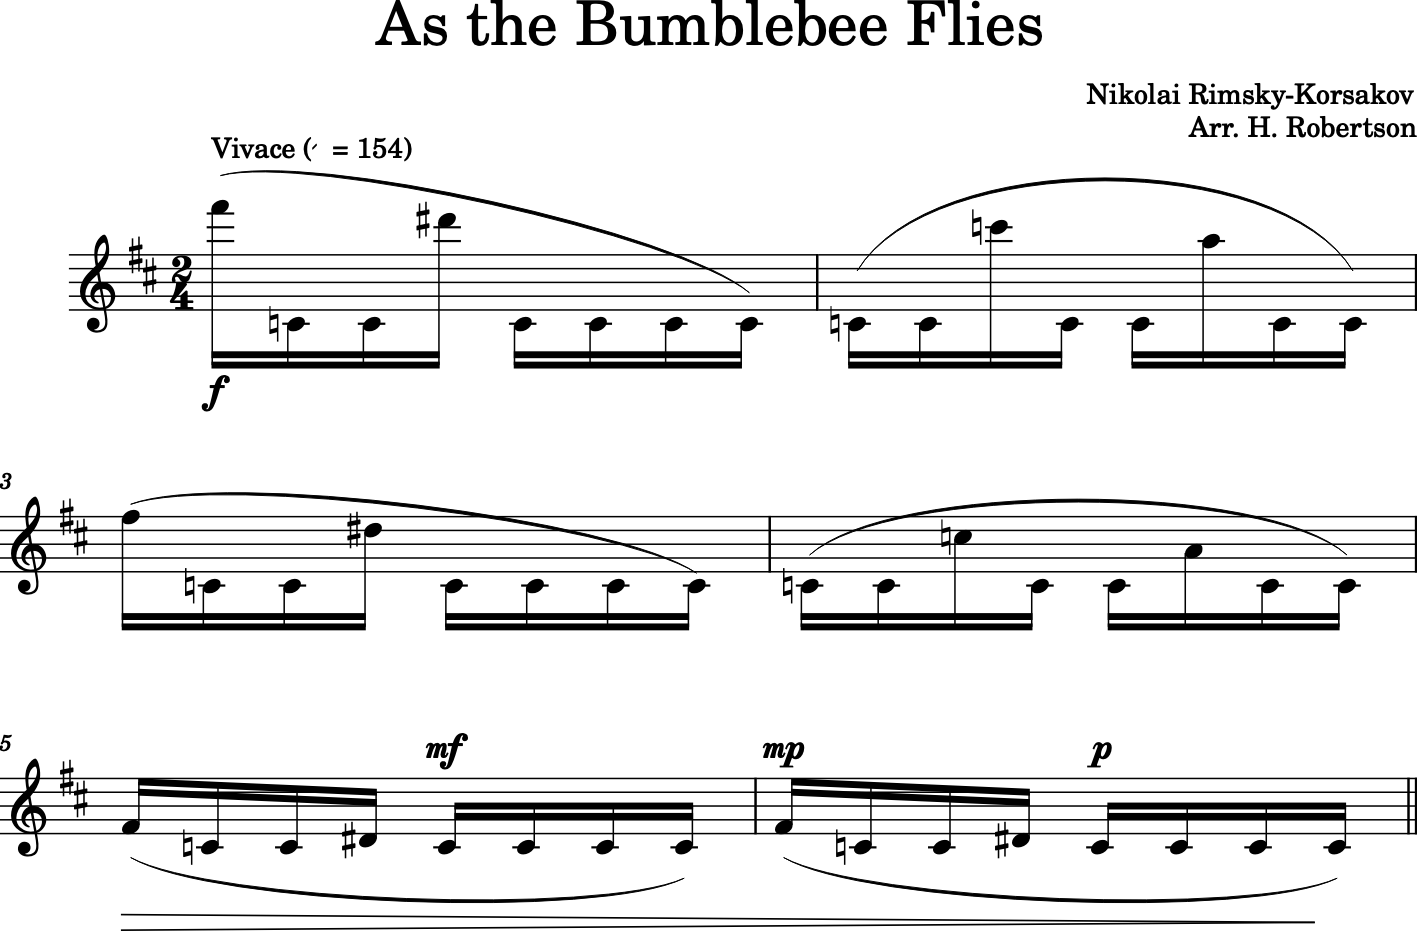

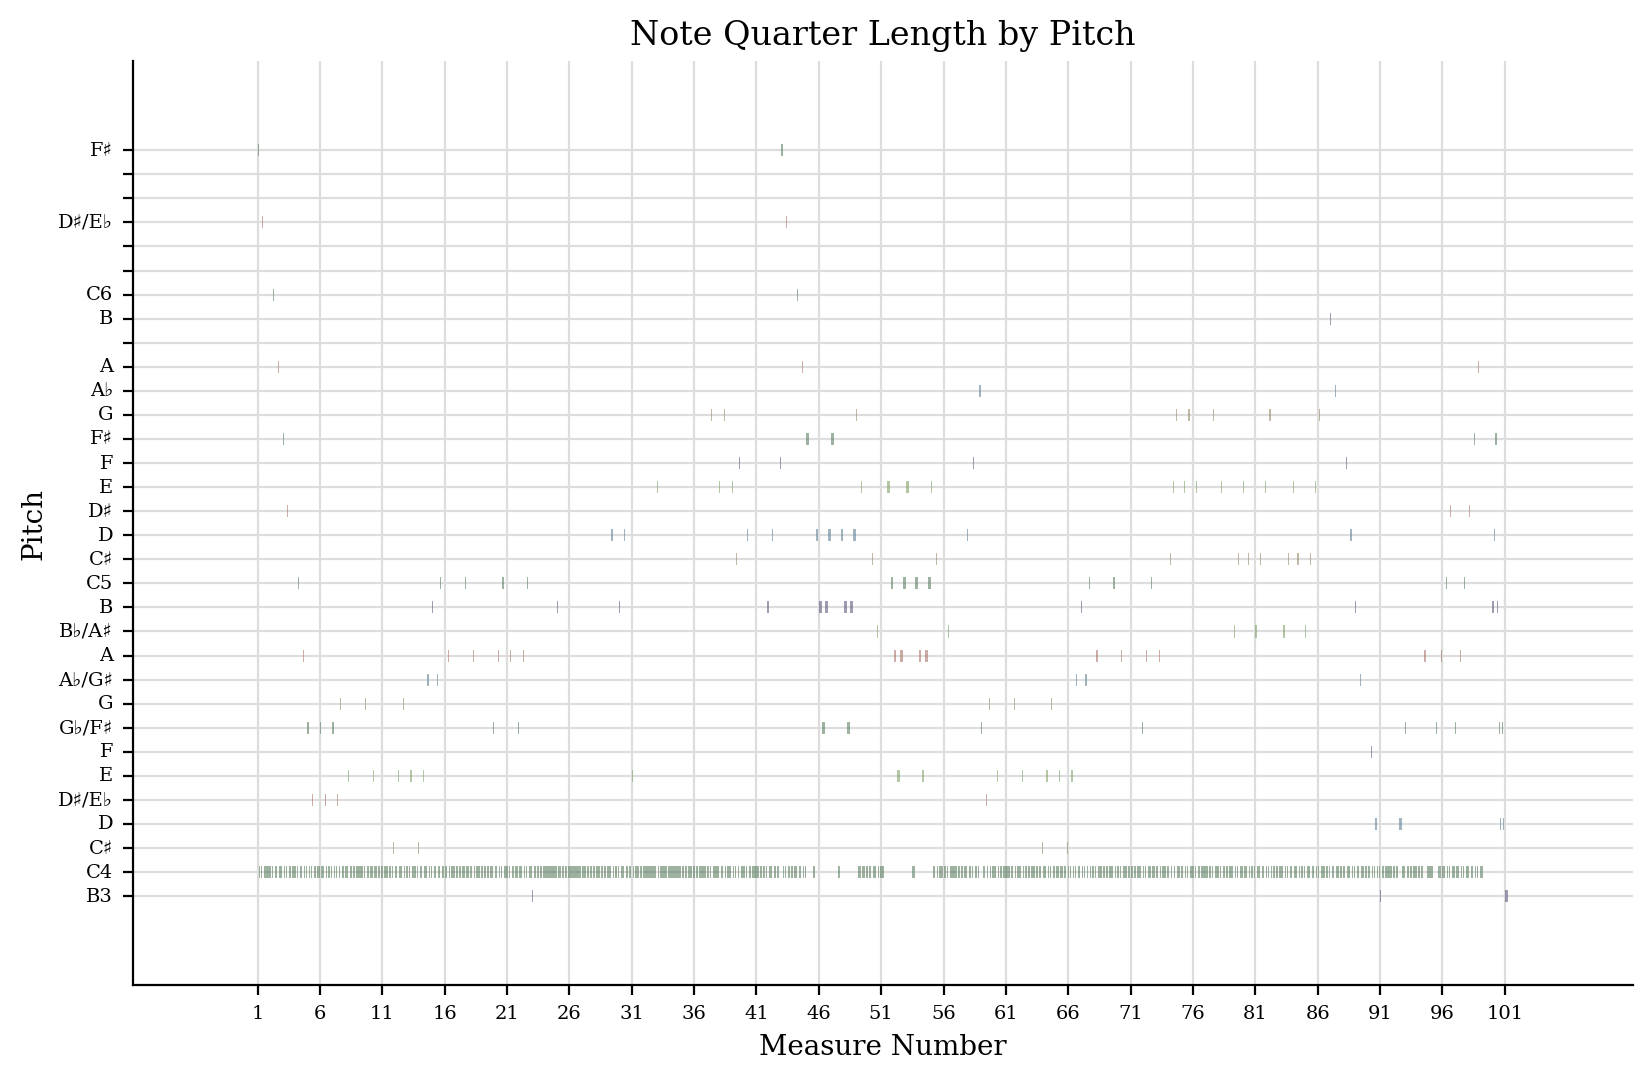

In [89]:
score_crow.measures(1,6).show()
score_crow.show('midi')
score_crow.plot('pianoroll')

In [136]:
stream1 = score_crow.measures(1,3).getElementsByClass(stream.Part).first()

In [137]:
stream1.show('text')

{0.0} <music21.instrument.Clarinet 'P1: Clarinet'>
{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.expressions.TextExpression 'Vivace (\ue105 ...'>
    {0.0} <music21.layout.SystemLayout>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.tempo.MetronomeMark Quarter=154 (playback only)>
    {0.0} <music21.key.Key of D major>
    {0.0} <music21.meter.TimeSignature 2/4>
    {0.0} <music21.dynamics.Dynamic f>
    {0.0} <music21.note.Note F#>
    {0.25} <music21.note.Note C>
    {0.5} <music21.note.Note C>
    {0.75} <music21.note.Note D#>
    {1.0} <music21.note.Note C>
    {1.25} <music21.note.Note C>
    {1.5} <music21.note.Note C>
    {1.75} <music21.note.Note C>
{0.0} <music21.spanner.Slur <music21.note.Note F#><music21.note.Note C>>
{0.0} <music21.spanner.Slur <music21.note.Note C><music21.note.Note C>>
{0.0} <music21.spanner.Slur <music21.note.Note F#><music21.note.Note C>>
{2.0} <music21.stream.Measure 2 offset=2.0>
    {0.0} <music21.note.Note C>
    {0.25} <mus

In [145]:
for n in stream1:
    print(n)

P1: Clarinet
<music21.stream.Measure 1 offset=0.0>
<music21.spanner.Slur <music21.note.Note F#><music21.note.Note C>>
<music21.spanner.Slur <music21.note.Note C><music21.note.Note C>>
<music21.spanner.Slur <music21.note.Note F#><music21.note.Note C>>
<music21.stream.Measure 2 offset=2.0>
<music21.stream.Measure 3 offset=4.0>


In [154]:
n = stream1[3]

In [155]:
stream1.index(n)

3

In [164]:
vars(score_crow)

{'_id': None,
 '_activeSite': None,
 '_naiveOffset': 0.0,
 '_activeSiteStoredOffset': None,
 '_derivation': <Derivation of <music21.stream.Score 0x124b4cb50> from <music21.stream.Score 0x107110d90> via '__deepcopy__'>,
 '_style': None,
 '_editorial': None,
 '_duration': None,
 '_priority': 0,
 '_cache': {'elements': [<music21.text.TextBox 'Flight of ...'>,
   <music21.text.TextBox 'for B♭- Cl...'>,
   <music21.text.TextBox 'Comp.: Rim...'>,
   <music21.stream.Part Clarinet>,
   <music21.layout.ScoreLayout>]},
 'groups': [],
 'sites': <music21.sites.Sites at 0x124bf4080>,
 '_offsetDict': {4898541136: (0.0, <music21.text.TextBox 'Flight of ...'>),
  4696153168: (0.0, <music21.text.TextBox 'for B♭- Cl...'>),
  4912578640: (0.0, <music21.text.TextBox 'Comp.: Rim...'>),
  4912582096: (0.0, <music21.metadata.Metadata object at 0x124d00dd0>),
  4884316304: (0.0, <music21.stream.Part Clarinet>),
  4965591952: (0.0, <music21.layout.ScoreLayout>)},
 '_elements': [<music21.text.TextBox 'Flight of

In [186]:
s = score_crow.getElementsByClass(stream.Part).first()

In [173]:
type(s)

music21.stream.base.Part

In [189]:
s_notes = s.recurse().getElementsByClass(note.Note)

In [193]:
# s_notes.stream().pop(0)
len(s_notes)

716

In [194]:
s_notes.stream().pop(1)

<music21.note.Note F>

In [181]:
s.show('text')

{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.expressions.TextExpression 'Vivace (\ue105 ...'>
    {0.0} <music21.layout.SystemLayout>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.tempo.MetronomeMark Quarter=154 (playback only)>
    {0.0} <music21.key.Key of D major>
    {0.0} <music21.meter.TimeSignature 2/4>
    {0.0} <music21.dynamics.Dynamic f>
    {0.0} <music21.note.Note F#>
    {0.25} <music21.note.Note F>
    {0.5} <music21.note.Note E>
    {0.75} <music21.note.Note D#>
    {1.0} <music21.note.Note E>
    {1.25} <music21.note.Note D#>
    {1.5} <music21.note.Note D>
    {1.75} <music21.note.Note C#>
{0.0} <music21.spanner.Slur <music21.note.Note F#><music21.note.Note C#>>
{0.0} <music21.spanner.Slur <music21.note.Note D><music21.note.Note G>>
{0.0} <music21.spanner.Slur <music21.note.Note F#><music21.note.Note C#>>
{0.0} <music21.spanner.Slur <music21.note.Note D><music21.note.Note G>>
{0.0} <music21.dynamics.Diminuendo <music21.note.Note F#><music21.